<a href="https://colab.research.google.com/github/kavya1234567889/programs/blob/main/iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded=files.upload()

Saving Iris.csv to Iris.csv


In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

In [5]:
df=df.drop(columns=['Id'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
df['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [9]:
df.isna().sum()

,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


<Axes: >

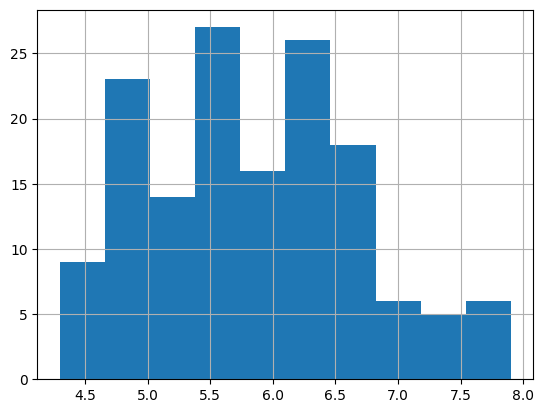

In [10]:
df['SepalLengthCm'].hist()

<Axes: >

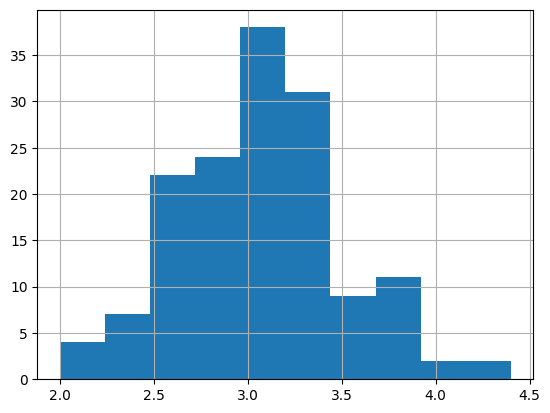

In [11]:
df['SepalWidthCm'].hist()

<Axes: >

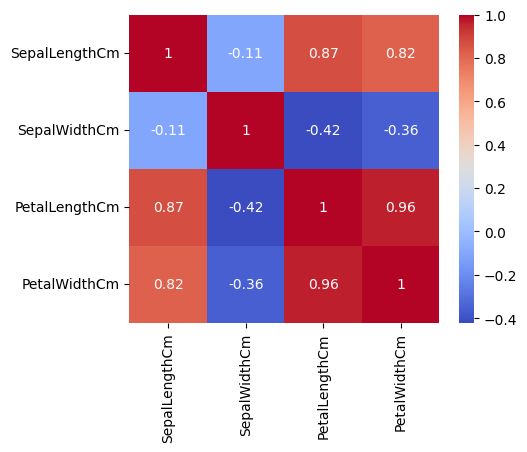

In [12]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(corr,annot=True,ax=ax,cmap='coolwarm')

In [13]:
px.scatter(df,x='Species',y='PetalWidthCm')

In [14]:
px.line(df,x='Species',y='SepalWidthCm')

In [15]:
px.scatter(df,x='Species',y='PetalLengthCm')

In [16]:
px.scatter(df,x='Species',y='SepalLengthCm')

In [17]:
px.scatter(df,x='Species',y='SepalWidthCm')

In [18]:
px.scatter_matrix(df,color='Species',title='Iris',dimensions=['SepalLengthCm','SepalWidthCm'])

In [19]:
color=['red','orange','blue']
Name=['Iris-virginica','Iris-versicolor','Iris-sentosa']

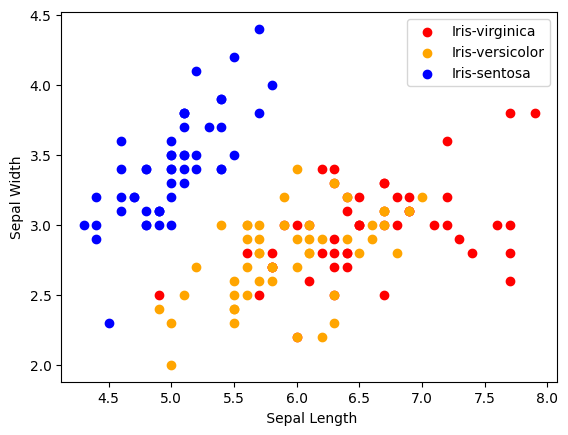

In [20]:
for i in range(3):
  species_for_filter = 'Iris-setosa' if Name[i] == 'Iris-sentosa' else Name[i]
  x=df[df['Species']==species_for_filter]
  plt.scatter(x['SepalLengthCm'],x['SepalWidthCm'],color=color[i],label=Name[i])
  plt.xlabel(" Sepal Length")
  plt.ylabel("Sepal Width")
  plt.legend()

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [22]:
df['Species'] = le.fit_transform(df['Species'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [23]:
from sklearn.model_selection import train_test_split
x = df.drop(columns=['Species'])
y = df['Species']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)


In [25]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
print("accuracy:",model.score(x_test,y_test)*100)

accuracy: 96.66666666666667


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
model = DecisionTreeClassifier()
model.fit(x_train,y_train)
print("accuracy:",model.score(x_test,y_test)*100)

accuracy: 93.33333333333333


In [26]:
data = 8, 3.755, 7, 2
data_array = np.array([data])
data_array
predic = model.predict(data_array)
predic

array([2])

In [28]:
catagory = ['iris-santosa','Iris-Versicolor','Iris-Virginica']
print(catagory[int(predic[0])])

Iris-Virginica


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,f1_score
model = RandomForestClassifier()
model.fit(x_train,y_train)
y_pred= model.predict(x_test)
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.88      0.93         8
           2       0.89      1.00      0.94         8

    accuracy                           0.97        30
   macro avg       0.96      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30

